In [9]:
!pip install matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [14]:
# 📦 Importação das bibliotecas necessárias
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 📦 Importa a função para carregar o dataset
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# 🔽 Carrega o dataset Iris
iris = load_iris()

# 🧾 Converte para um DataFrame do pandas
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Adiciona a coluna alvo (espécie da flor)
df["target"] = iris.target
df["target_name"] = df["target"].apply(lambda x: iris.target_names[x])

# 👀 Exibe as 5 primeiras linhas
print("Dataset Iris carregado com sucesso!")
df.head()

Dataset Iris carregado com sucesso!


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


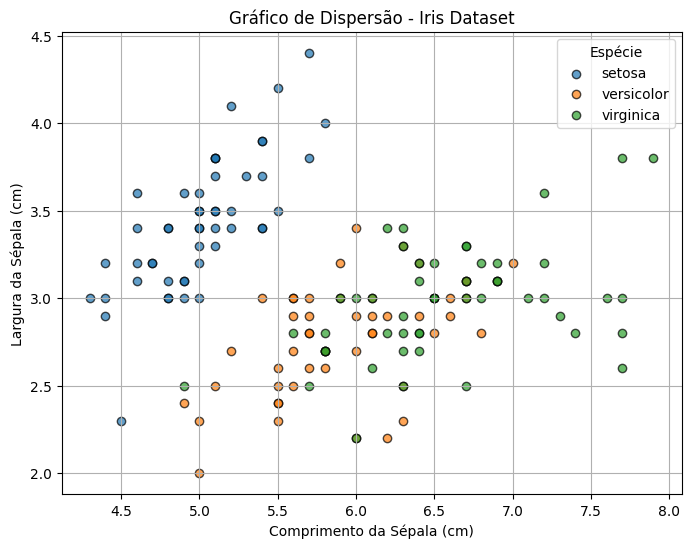

In [ ]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = [iris.target_names[t] for t in iris.target]

# 🎨 Cria um gráfico de dispersão
plt.figure(figsize=(8, 6))
for species in df["species"].unique():
    subset = df[df["species"] == species]
    plt.scatter(
        subset["sepal length (cm)"],
        subset["sepal width (cm)"],
        label=species,
        alpha=0.7,
        edgecolors="k"
    )

# 🧾 Configurações do gráfico
plt.title("Gráfico de Dispersão - Iris Dataset")
plt.xlabel("Comprimento da Sépala (cm)")
plt.ylabel("Largura da Sépala (cm)")
plt.legend(title="Espécie")
plt.grid(True)
plt.show()


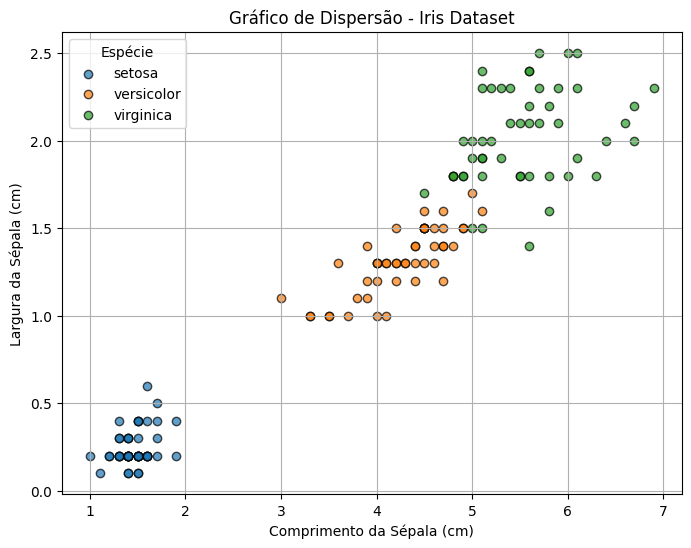

In [17]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = [iris.target_names[t] for t in iris.target]

# 🎨 Cria um gráfico de dispersão
plt.figure(figsize=(8, 6))
for species in df["species"].unique():
    subset = df[df["species"] == species]
    plt.scatter(
        subset["petal length (cm)"],
        subset["petal width (cm)"],
        label=species,
        alpha=0.7,
        edgecolors="k"
    )

# 🧾 Configurações do gráfico
plt.title("Gráfico de Dispersão - Iris Dataset")
plt.xlabel("Comprimento da Sépala (cm)")
plt.ylabel("Largura da Sépala (cm)")
plt.legend(title="Espécie")
plt.grid(True)
plt.show()


Tamanho do conjunto de treino: 120 amostras
Tamanho do conjunto de validação: 30 amostras

Acurácia no conjunto de validação: 90.00%

Relatório de Classificação:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



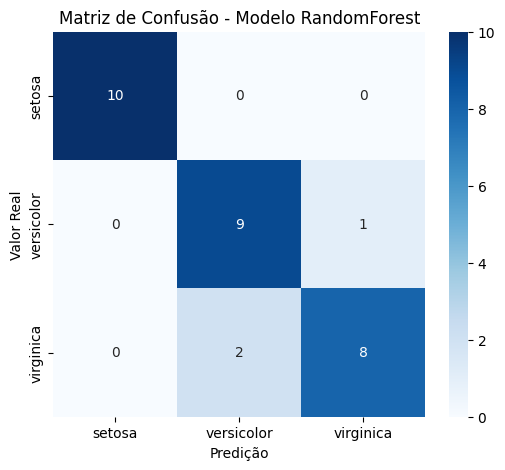

In [ ]:
iris = load_iris()
X = iris.data              # features (características)
y = iris.target            # target (rótulos das classes)
target_names = iris.target_names

# ✂️ Divide o dataset em treino (80%) e validação (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamanho do conjunto de treino: {len(X_train)} amostras")
print(f"Tamanho do conjunto de validação: {len(X_val)} amostras")

# 🌳 Cria e treina o modelo de classificação
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 🔍 Faz previsões no conjunto de validação
y_pred = model.predict(X_val)

# 📈 Avalia o desempenho
acc = accuracy_score(y_val, y_pred)
print(f"\nAcurácia no conjunto de validação: {acc:.2%}\n")

print("Relatório de Classificação:")
print(classification_report(y_val, y_pred, target_names=target_names))

# 🧩 Matriz de Confusão
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.title("Matriz de Confusão - Modelo RandomForest")
plt.xlabel("Predição")
plt.ylabel("Valor Real")
plt.show()


In [12]:
def prever_especie(valores):
    """
    Recebe um array ou lista de valores no formato:
    [comprimento_sépala, largura_sépala, comprimento_pétala, largura_pétala]
    e retorna o nome da espécie prevista.
    """
    valores = np.array(valores).reshape(1, -1)  # garante formato 2D
    pred = model.predict(valores)
    especie = iris.target_names[pred[0]]
    return especie

In [16]:
exemplo = [5.1, 3.5, 1.4, 0.2]  # valores típicos da espécie Setosa
resultado = prever_especie(exemplo)
resultado

'setosa'